## 1. Data Collection

In [40]:
import yfinance as yf 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime 

start_date=datetime.datetime(2015, 9, 26)
end_date=datetime.datetime(2026, 3, 1)
peloton = yf.Ticker("PTON")
data=peloton.history(start=start_date, end=end_date)
#print(data.to_string())

data.head()



,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2019-09-26 00:00:00-04:00,27.17,27.98,24.75,25.76,47067700,0.0,0.0
2019-09-27 00:00:00-04:00,26.17,26.17,23.75,25.24,15976000,0.0,0.0
2019-09-30 00:00:00-04:00,25.26,25.85,25.00,25.10,4482900,0.0,0.0
2019-10-01 00:00:00-04:00,25.00,25.17,22.51,22.51,8816100,0.0,0.0
2019-10-02 00:00:00-04:00,22.25,23.18,21.76,22.60,9454700,0.0,0.0


## 2. Exploration & Cleaning

In [41]:
data.shape

(1614, 7)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1614 entries, 2019-09-26 00:00:00-04:00 to 2026-02-27 00:00:00-05:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1614 non-null   float64
 1   High          1614 non-null   float64
 2   Low           1614 non-null   float64
 3   Close         1614 non-null   float64
 4   Volume        1614 non-null   int64  
 5   Dividends     1614 non-null   float64
 6   Stock Splits  1614 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 100.9 KB


In [43]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,1614.000000,1614.000000,1614.000000,1614.000000,1.614000e+03,1614.0,1614.0
mean,33.320124,34.315732,32.288821,33.327788,1.314535e+07,0.0,0.0
std,41.217139,42.276672,40.099628,41.244393,1.301342e+07,0.0,0.0
min,2.900000,3.010000,2.700000,2.880000,1.185400e+06,0.0,0.0
25%,6.562500,6.796250,6.395500,6.590000,7.324800e+06,0.0,0.0
50%,9.975000,10.375000,9.610000,10.005000,1.033215e+07,0.0,0.0
75%,40.647499,42.677500,38.767499,40.977500,1.461235e+07,0.0,0.0
max,166.100006,171.089996,163.960007,167.419998,2.465291e+08,0.0,0.0


In [44]:
#timestamp of highest closing
data["Close"].idxmax()

Timestamp('2021-01-13 00:00:00-0500', tz='America/New_York')

In [45]:
#amount of highest closing 
data.loc[data["Close"].idxmax()]    

Open            1.565030e+02
High            1.690000e+02
Low             1.565030e+02
Close           1.674200e+02
Volume          1.061890e+07
Dividends       0.000000e+00
Stock Splits    0.000000e+00
Name: 2021-01-13 00:00:00-05:00, dtype: float64

In [46]:
data.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [47]:
data= data.drop(columns=['Dividends', 'Stock Splits'])
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-09-26 00:00:00-04:00,27.17,27.98,24.75,25.76,47067700
2019-09-27 00:00:00-04:00,26.17,26.17,23.75,25.24,15976000
2019-09-30 00:00:00-04:00,25.26,25.85,25.00,25.10,4482900
2019-10-01 00:00:00-04:00,25.00,25.17,22.51,22.51,8816100
2019-10-02 00:00:00-04:00,22.25,23.18,21.76,22.60,9454700


In [48]:
data.index=pd.to_datetime(data.index.tz_localize(None)).normalize() #removes timezone  w tz_localize + pd.to_datetime keeps it as pandas datetime, and normalize sets time to 00:00:00
data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2019-09-26,27.17,27.98,24.75,25.76,47067700
2019-09-27,26.17,26.17,23.75,25.24,15976000
2019-09-30,25.26,25.85,25.00,25.10,4482900
2019-10-01,25.00,25.17,22.51,22.51,8816100
2019-10-02,22.25,23.18,21.76,22.60,9454700


In [49]:
#I let the data gudide my analysis, then added context :P
data["Close"].sort_values(ascending=False).head(15) #highest 
#result they all cluster around the same period for obvious reasons

Date
2021-01-13    167.419998
2021-01-14    165.250000
2020-12-23    162.759995
2020-12-24    162.720001
2020-12-22    161.210007
2021-01-22    159.750000
2021-01-08    158.880005
2021-01-21    158.130005
2021-01-15    157.809998
2021-02-04    157.529999
2021-01-25    157.139999
2021-01-12    156.039993
2021-01-20    155.789993
2020-12-30    154.960007
2021-02-12    154.669998
Name: Close, dtype: float64

In [50]:
data["Close"].sort_values(ascending=True).head(15) #lowest 

Date
2024-08-14    2.88
2024-08-12    2.89
2024-08-07    2.92
2024-08-08    2.98
2024-08-09    2.99
2024-05-28    2.99
2024-08-13    3.02
2024-04-25    3.03
2024-04-19    3.03
2024-04-22    3.05
2024-04-24    3.06
2024-04-18    3.06
2024-08-06    3.07
2024-08-05    3.08
2024-04-17    3.09
Name: Close, dtype: float64

In [51]:
# now resampled with only allowing one value for a year 
data["Close"].resample("YE").max().nlargest(5)  #highest 


Date
2021-12-31    167.419998
2020-12-31    162.759995
2022-12-31     38.770000
2019-12-31     36.840000
2023-12-31     16.980000
Name: Close, dtype: float64

In [52]:
# now resampled with only allowing one value for a year 
data["Close"].resample("YE").min().nsmallest(5)  #highest 

Date
2024-12-31    2.88
2026-12-31    4.02
2023-12-31    4.30
2025-12-31    5.00
2022-12-31    6.93
Name: Close, dtype: float64

## Peloton Stock Price Overview (2019-2026)
A full view of Peloton's stock price and trading volume since IPO. 
The chart shows a clear rise during COVID lockdowns, peaking in 
January 2021, followed by a sharp and sustained decline.

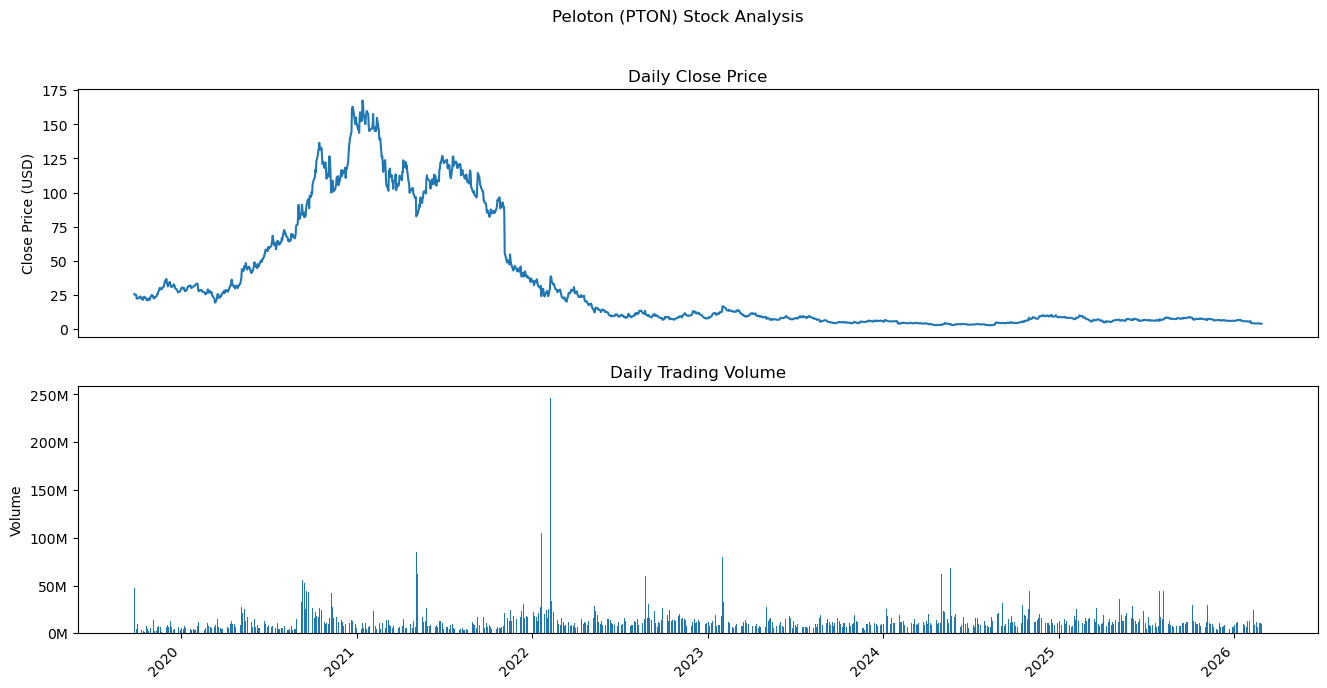

In [53]:
# The Big Picture of Peloton's Stock Prices since ipo 
plt.style.use('default')
figure, axis = plt.subplots(2, figsize=(16, 8))
figure.suptitle("Peloton (PTON) Stock Analysis")

# Close Price chart
axis[0].plot(data.index, data['Close'])
axis[0].set_title("Daily Close Price")
axis[0].set_ylabel("Close Price (USD)")
axis[0].axes.get_xaxis().set_visible(False)

# Volume chart
axis[1].bar(data.index, data['Volume'])
axis[1].set_title("Daily Trading Volume")
axis[1].set_ylabel("Volume")
axis[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
)

# Tweak chart
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.show()

## Key Events Research

After watching a YouTube video covering Peloton's rise and fall, 
I identified several key dates that allegedly impacted the stock price. 
I cross-referenced these with news sources to confirm the exact dates 
and added them as annotations to understand how each event 
correlated with price movement.

In [54]:
events = {
    "2019-09-26": "Peloton IPO",
    "2021-01-13": "All Time High ~$167",
    "2021-05-05": "Treadmill Recall",
    "2021-12-09": "Mr. Big AJLT Scene",
    "2022-02-08": "CEO John Foley Resigns",
    "2024-08-14": "All Time Low ~$2.88",
}

In [55]:
#Converting the keys to pandas datetime
events = {pd.Timestamp(k): v for k, v in events.items()}

## Key Events Annotation
Now let's overlay the key events that drove Peloton's stock movements.

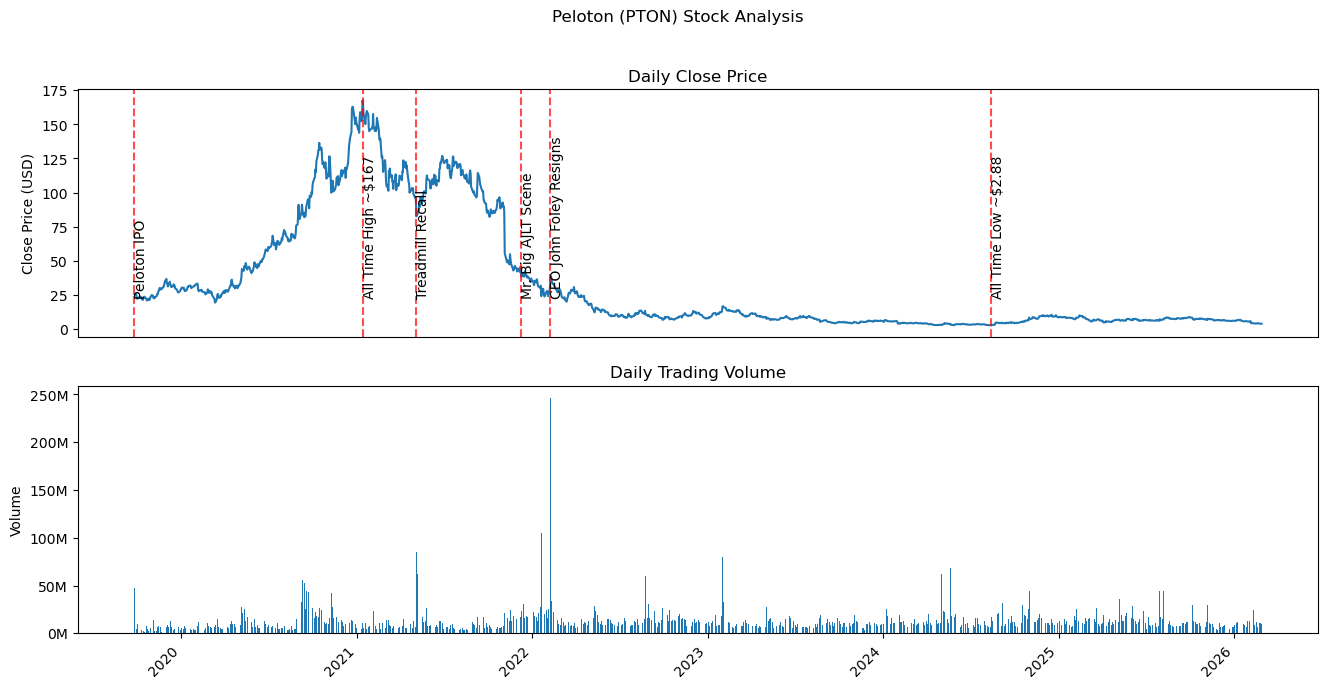

In [56]:
plt.style.use('default')
figure, axis = plt.subplots(2, figsize=(16, 8))
figure.suptitle("Peloton (PTON) Stock Analysis")

# Close Price chart
axis[0].plot(data.index, data['Close'])
axis[0].set_title("Daily Close Price")
axis[0].set_ylabel("Close Price (USD)")
axis[0].axes.get_xaxis().set_visible(False)

# Event annotations
for date, label in events.items():
    axis[0].axvline(x=date, color='red', linestyle='--', alpha=0.7)
    axis[0].text(x=date, y=25, s=label, rotation=90)

# Volume chart
axis[1].bar(data.index, data['Volume'])
axis[1].set_title("Daily Trading Volume")
axis[1].set_ylabel("Volume")
axis[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M')
)
# Tweak chart
plt.xticks(rotation=45, ha='right')
plt.subplots_adjust(bottom=0.2)
plt.show()

In [57]:
#Peak covid dates 

peak_data= data.loc["2020-03-01":"2021-03-01"]
peak_data.head()

,Open,High,Low,Close,Volume
Date,,,,,
2020-03-02,27.200001,29.320000,26.330000,27.920000,6230300
2020-03-03,27.340000,27.500000,26.180000,26.684999,7938600
2020-03-04,27.010000,27.450001,25.780001,27.250000,5606200
2020-03-05,26.510000,27.180000,25.844999,27.100000,5464800
2020-03-06,25.950001,26.141001,24.360001,24.980000,7334400


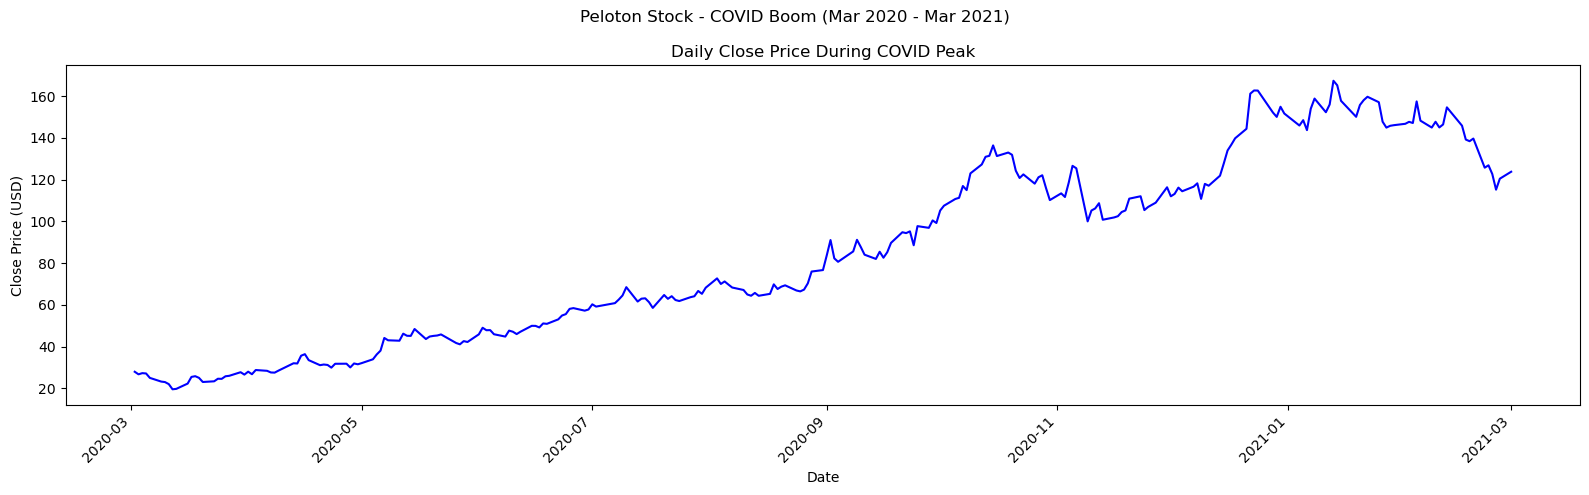

In [58]:
plt.style.use('default')
fig, ax = plt.subplots(1, figsize=(16, 5))
fig.suptitle("Peloton Stock - COVID Boom (Mar 2020 - Mar 2021)")

ax.plot(peak_data.index, peak_data['Close'], color='blue')
ax.set_title("Daily Close Price During COVID Peak")
ax.set_ylabel("Close Price (USD)")
ax.set_xlabel("Date")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [59]:
peak_lowest_data= data.loc["2023-09-01":"2024-09-01"]
peak_lowest_data.head()


,Open,High,Low,Close,Volume
Date,,,,,
2023-09-01,6.410,6.630,6.41,6.55,7456600
2023-09-05,6.421,6.710,6.37,6.59,6689800
2023-09-06,6.560,6.660,6.05,6.10,11118700
2023-09-07,5.920,5.965,5.68,5.82,8153600
2023-09-08,5.770,5.845,5.39,5.45,14779900


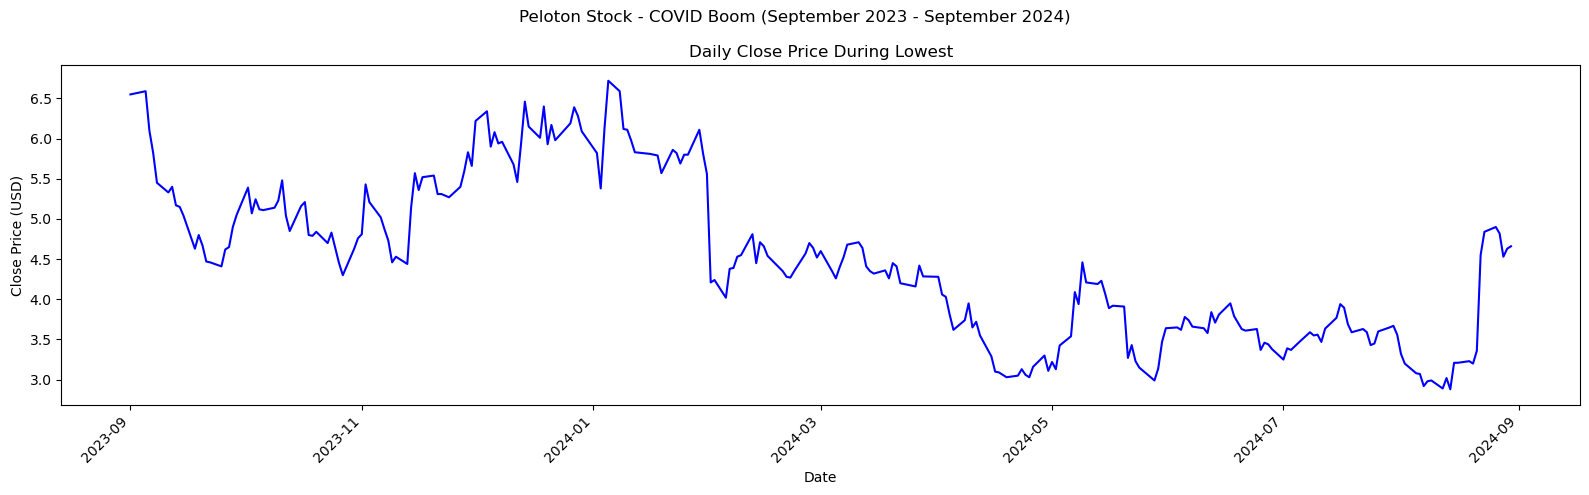

In [60]:
plt.style.use('default')
fig, ax = plt.subplots(1, figsize=(16, 5))
fig.suptitle("Peloton Stock - COVID Boom (September 2023 - September 2024)")

ax.plot(peak_lowest_data.index, peak_lowest_data['Close'], color='blue')
ax.set_title("Daily Close Price During Lowest")
ax.set_ylabel("Close Price (USD)")
ax.set_xlabel("Date")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()